In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
nodes_df = pd.read_excel('./Gas Network Data.xlsx', sheet_name='Nodes')
pipes_df = pd.read_excel('./Gas Network Data.xlsx', sheet_name='Pipelines')

months = [str(m).zfill(2) + '-2024' for m in range(1, 13)]

res_total = pd.concat(
    [pd.read_excel('./input/Gas Cons Distrib.xlsx', sheet_name=m)['Physical Flow (MNm3)'] for m in months],
    ignore_index=True
).values.astype(np.float32)

ind_total = pd.concat(
    [pd.read_excel('./input/Gas Cons Ind.xlsx', sheet_name=m)['Physical Flow (MNm3)'] for m in months],
    ignore_index=True
).values.astype(np.float32)

exp_total = pd.concat(
    [pd.read_excel('./input/Gas Cons Export.xlsx', sheet_name=m)['Physical Flow (MNm3)'] for m in months],
    ignore_index=True
).values.astype(np.float32)

# q : débit dans chaque pipeline [T, 33]
# colonnes 0-32 = pipelines 1-33 dans l'ordre du sheet Pipelines
q_full = pd.concat(
    [pd.read_excel('./output/Decision_variablesRU.xlsx', sheet_name=f'q-{m}').iloc[:, 1:] for m in months],
    ignore_index=True
).values.astype(np.float32)  # [8784, 33]

# g : injection aux 4 puits [T, 4]
g_full = pd.concat(
    [pd.read_excel('./output/Decision_variablesRU.xlsx', sheet_name=f'g-{m}')[[0, 1, 2, 3]] for m in months],
    ignore_index=True
).values.astype(np.float32)

print('res_total :', res_total.shape)
print('q_full    :', q_full.shape, '← nouveau')
print('g_full    :', g_full.shape)

res_total : (8784,)
q_full    : (8784, 33) ← nouveau
g_full    : (8784, 4)


In [3]:
N     = 28
T     = 8784
W_IN  = 72
W_OUT = 24
BLOCK = W_IN + W_OUT

nodes_df  = nodes_df.sort_values('Gas Node').reset_index(drop=True)
res_share = nodes_df['Res_Load_share_%'].values.astype(np.float32)
ind_share = nodes_df['Ind_Load_share_%'].values.astype(np.float32)
exp_share = nodes_df['Exp_Load_share_%'].values.astype(np.float32)

X_cons = np.stack([
    np.outer(res_total, res_share),
    np.outer(ind_total, ind_share),
    np.outer(exp_total, exp_share),
], axis=-1).astype(np.float32)

X_global = np.stack([
    np.tile(res_total[:, None], (1, N)),
    np.tile(ind_total[:, None], (1, N)),
    np.tile(exp_total[:, None], (1, N)),
], axis=-1).astype(np.float32)

hours    = np.arange(T)
hour_sin = np.sin(2 * np.pi * (hours % 24)      / 24).astype(np.float32)
hour_cos = np.cos(2 * np.pi * (hours % 24)      / 24).astype(np.float32)
dow_sin  = np.sin(2 * np.pi * (hours // 24 % 7) / 7 ).astype(np.float32)
dow_cos  = np.cos(2 * np.pi * (hours // 24 % 7) / 7 ).astype(np.float32)
time_feats = np.stack([
    np.tile(hour_sin[:, None], (1, N)),
    np.tile(hour_cos[:, None], (1, N)),
    np.tile(dow_sin[:,  None], (1, N)),
    np.tile(dow_cos[:,  None], (1, N)),
], axis=-1).astype(np.float32)

g_node = np.zeros((T, N), dtype=np.float32)
WELL_GLOBAL_IDX = [0, 4, 16, 17]
g_node[:, WELL_GLOBAL_IDX] = g_full

X_full = np.concatenate([X_cons, X_global, time_feats, g_node[:, :, None]], axis=-1)  # [T, N, 11]

# Normalisation
cols_to_norm = list(range(0, 6)) + [10]
x_scaler = StandardScaler().fit(X_full[:, :, cols_to_norm].reshape(-1, len(cols_to_norm)))
X_full[:, :, cols_to_norm] = x_scaler.transform(
    X_full[:, :, cols_to_norm].reshape(-1, len(cols_to_norm))
).reshape(T, N, len(cols_to_norm))

Y_all    = g_full.astype(np.float32)
y_scaler = StandardScaler().fit(Y_all)
Y_norm   = y_scaler.transform(Y_all).astype(np.float32)

print(f'X_full : {X_full.shape}  (T x N x 11 features noeuds)')

X_full : (8784, 28, 11)  (T x N x 11 features noeuds)


In [4]:
# ── Topologie fixe ─────────────────────────────────────────────────────────────
pipes_df = pipes_df[['Pipeline', 'From node', 'To node',
                      'Compressor factor', 'Estimated lenght [km]']].copy()
pipes_df['Estimated lenght [km]'] = pipes_df['Estimated lenght [km]'].fillna(0.0)
pipes_df['Compressor factor']     = pipes_df['Compressor factor'].fillna(1.0)

# Construction edge_index et mapping pipeline → arête
# Pour chaque pipeline p (index 0-based) :
#   arête 2*p   = u→v  (direction forward)
#   arête 2*p+1 = v→u  (direction backward)
edge_pairs   = []
pipe_to_edge = []   # pipe_to_edge[p] = (idx_forward, idx_backward)

for i, row in pipes_df.iterrows():
    u = int(row['From node']) - 1
    v = int(row['To node'])   - 1
    idx_fwd = len(edge_pairs)
    edge_pairs.append((u, v))
    idx_bwd = len(edge_pairs)
    edge_pairs.append((v, u))
    pipe_to_edge.append((idx_fwd, idx_bwd))

edge_index = np.array(edge_pairs, dtype=np.int64).T   # [2, 66]
E          = edge_index.shape[1]                       # 66

print(f'edge_index : {edge_index.shape}')
print(f'pipe_to_edge[0] : {pipe_to_edge[0]}  (pipeline 1 → arêtes 0 et 1)')

# ── Features statiques des arêtes (compressor + length) ──────────────────────
static_edge = np.array([
    [pipes_df.iloc[p]['Compressor factor'],
     pipes_df.iloc[p]['Estimated lenght [km]']]
    for p, (idx_f, idx_b) in enumerate(pipe_to_edge)   # ← p via enumerate
    for _ in (idx_f, idx_b)
], dtype=np.float32)  # [66, 2]

static_scaler     = StandardScaler().fit(static_edge)
static_edge_norm  = static_scaler.transform(static_edge).astype(np.float32)

# ── q dynamique : [T, 66] ─────────────────────────────────────────────────────
# q_full[t, p] = débit du pipeline p+1 au temps t
# On assigne la même valeur |q| aux deux directions (forward et backward)
# Le signe n'est pas donné dans les données donc on prend la valeur absolue
Q_edge = np.zeros((T, E), dtype=np.float32)
for p, (idx_f, idx_b) in enumerate(pipe_to_edge):
    Q_edge[:, idx_f] = np.abs(q_full[:, p])
    Q_edge[:, idx_b] = np.abs(q_full[:, p])

# Normalisation de q
q_scaler    = StandardScaler().fit(Q_edge.reshape(-1, 1))
Q_edge_norm = q_scaler.transform(Q_edge.reshape(-1, 1)).reshape(T, E).astype(np.float32)

print(f'Q_edge_norm : {Q_edge_norm.shape}  (T x 66 arêtes)')
print(f'static_edge_norm : {static_edge_norm.shape}  (66 x 2 features statiques)')

# Features arête totales par timestep : [T, 66, 3]
# = [q_dynamique(1), compressor(1), length(1)]
EA_full = np.concatenate([
    Q_edge_norm[:, :, None],                               # [T, 66, 1]  dynamique
    np.tile(static_edge_norm[None, :, :], (T, 1, 1)),      # [T, 66, 2]  statique
], axis=-1).astype(np.float32)                             # [T, 66, 3]

print(f'EA_full : {EA_full.shape}  (T x 66 x 3 features arêtes)')

ei = torch.tensor(edge_index, dtype=torch.long, device=device)  # [2, 66]

edge_index : (2, 66)
pipe_to_edge[0] : (0, 1)  (pipeline 1 → arêtes 0 et 1)
Q_edge_norm : (8784, 66)  (T x 66 arêtes)
static_edge_norm : (66, 2)  (66 x 2 features statiques)
EA_full : (8784, 66, 3)  (T x 66 x 3 features arêtes)


In [5]:
EA_full = Q_edge_norm[:, :, None]   # [T, 66, 1]  ← q uniquement

starts = np.arange(0, T - BLOCK + 1, 6)
X_win  = np.stack([X_full[s : s + W_IN]  for s in starts])
EA_win = np.stack([EA_full[s : s + W_IN] for s in starts])   # [S, 72, 66, 1]
Y_win  = np.stack([Y_norm[s + W_IN : s + BLOCK] for s in starts])

# re-split
S       = len(starts)
s_train = int(0.70 * S)
s_val   = int(0.85 * S)
X_train, Y_train = X_win[:s_train],      Y_win[:s_train]
X_val,   Y_val   = X_win[s_train:s_val], Y_win[s_train:s_val]
X_test,  Y_test  = X_win[s_val:],        Y_win[s_val:]
EA_train = EA_win[:s_train]
EA_val   = EA_win[s_train:s_val]
EA_test  = EA_win[s_val:]

print('EA_win shape:', EA_win.shape)  # doit finir par 1

EA_win shape: (1449, 72, 66, 1)


In [6]:
class GasDataset(Dataset):
    def __init__(self, X, EA, Y):
        self.X  = torch.tensor(X,  dtype=torch.float32)   # [S, 72, N, 11]
        self.EA = torch.tensor(EA, dtype=torch.float32)   # [S, 72, 66, 3]
        self.Y  = torch.tensor(Y,  dtype=torch.float32)   # [S, 24, 4]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.EA[idx], self.Y[idx]

BATCH = 32

train_loader = DataLoader(GasDataset(X_train, EA_train, Y_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(GasDataset(X_val,   EA_val,   Y_val),   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(GasDataset(X_test,  EA_test,  Y_test),  batch_size=BATCH, shuffle=False)

print(f'Batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')

Batches — train: 32  val: 7  test: 7


In [7]:
WELL_IDX = [0, 4, 16, 17]
H        = 96
IN_DIM   = 11
EDGE_DIM = 1
DROPOUT  = 0.2


class MessagePassingLayer(nn.Module):
    def __init__(self, h_dim, edge_dim, edge_h=16, dropout=0.2):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, edge_h), nn.ReLU(),
            nn.Linear(edge_h, 1),
        )
        self.W    = nn.Linear(h_dim, h_dim)
        self.norm = nn.LayerNorm(h_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, h, edge_index, ea):
        B, N, H = h.shape
        src, dst = edge_index[0], edge_index[1]
        w   = torch.sigmoid(self.edge_mlp(ea))   # [B, E, 1]
        msg = h[:, src, :] * w                   # [B, E, H]
        agg = torch.zeros(B, N, H, device=h.device)
        cnt = torch.zeros(N, device=h.device)
        idx = dst.view(1, -1, 1).expand(B, -1, H)
        agg.scatter_add_(1, idx, msg)
        cnt.scatter_add_(0, dst, torch.ones(len(dst), device=h.device))
        agg = agg / cnt.clamp(min=1).view(1, N, 1)
        return self.drop(self.norm(F.relu(self.W(h + agg))))


class GlobalAttention(nn.Module):
    def __init__(self, h_dim, n_heads=4, dropout=0.2):
        super().__init__()
        self.attn  = nn.MultiheadAttention(h_dim, n_heads, dropout=dropout, batch_first=True)
        self.norm  = nn.LayerNorm(h_dim)
        self.ff    = nn.Sequential(
            nn.Linear(h_dim, h_dim * 2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h_dim * 2, h_dim),
        )
        self.norm2 = nn.LayerNorm(h_dim)

    def forward(self, h):
        attn_out, _ = self.attn(h, h, h)
        h = self.norm(h + attn_out)
        h = self.norm2(h + self.ff(h))
        return h


class SimpleGNN(nn.Module):
    """
    Pour chaque heure t dans [0, 72) :
      1. Encoder MLP sur x[:, t, :, :]       → [B, N, H]
      2. Message Passing avec ea[:, t, :, :]  → [B, N, H]  (q de l'heure t)

    Séquence résultante [B, 72, N, H]
    Agrégation temporelle par attention       → [B, N, H]
    Global attention                          → [B, N, H]
    Decoder MLP (poids partagés + node_embed) → [B, 24, 4]
    """
    def __init__(self, in_dim=11, h_dim=96, edge_dim=1,
                 edge_h=16, n_mp_layers=2, n_heads=4,
                 w_out=24, dropout=0.2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(in_dim, h_dim), nn.LayerNorm(h_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h_dim,  h_dim), nn.LayerNorm(h_dim), nn.ReLU(), nn.Dropout(dropout),
        )

        self.mp_layers = nn.ModuleList([
            MessagePassingLayer(h_dim, edge_dim, edge_h, dropout)
            for _ in range(n_mp_layers)
        ])

        self.time_attn = nn.Linear(h_dim, 1)

        self.global_attn = GlobalAttention(h_dim, n_heads, dropout)

        self.decoder = nn.Sequential(
            nn.Linear(h_dim, h_dim), nn.LayerNorm(h_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h_dim, w_out),
        )

        # Identité apprise par puits : 4 vecteurs de taille h_dim
        self.node_embed = nn.Embedding(4, h_dim)

    def forward(self, x, ea_seq, edge_index):
        # x      : [B, 72, N, 11]
        # ea_seq : [B, 72, E, 1]
        B, W, N, F = x.shape

        h_seq = []
        for t in range(W):
            ht   = self.encoder(x[:, t, :, :].reshape(B * N, F)).reshape(B, N, -1)
            ea_t = ea_seq[:, t, :, :]   # [B, E, 1]
            for mp in self.mp_layers:
                ht = mp(ht, edge_index, ea_t)
            h_seq.append(ht)

        # Stack : [B, 72, N, H]
        h_seq = torch.stack(h_seq, dim=1)

        # Attention temporelle → [B, N, H]
        attn = torch.softmax(self.time_attn(h_seq), dim=1)
        h    = (h_seq * attn).sum(dim=1)

        # Attention globale
        h = self.global_attn(h)

        # Sélection des 4 puits + ajout de l'identité par nœud
        h_wells  = h[:, WELL_IDX, :]                           # [B, 4, H]
        node_ids = torch.arange(4, device=x.device)
        h_wells  = h_wells + self.node_embed(node_ids)         # [B, 4, H]

        out = self.decoder(h_wells)    # [B, 4, 24]
        return out.permute(0, 2, 1)    # [B, 24, 4]


model = SimpleGNN(
    in_dim      = IN_DIM,
    h_dim       = H,
    edge_dim    = EDGE_DIM,
    edge_h      = 16,
    n_mp_layers = 2,
    n_heads     = 4,
    w_out       = W_OUT,
    dropout     = DROPOUT,
).to(device)

print(f'Paramètres : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Paramètres : 117,051


C:\Users\yoans\anaconda3\envs\torch118\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  10 | train=0.7094  val=0.7280  val_smooth=0.7181  lr=1.00e-03
Epoch  20 | train=0.6825  val=0.7578  val_smooth=0.7460  lr=1.00e-03
Epoch  30 | train=0.6580  val=0.7970  val_smooth=0.7887  lr=5.00e-04
Epoch  40 | train=0.6468  val=0.7847  val_smooth=0.7946  lr=5.00e-04
Early stop à epoch 43


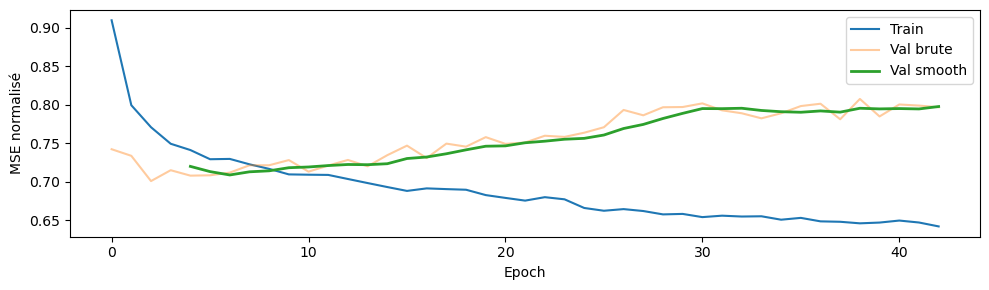

In [8]:
EPOCHS        = 300
LR            = 1e-3
PATIENCE      = 40
SMOOTH_WINDOW = 5

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=5e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, verbose=True
)

best_val_smooth = float('inf')
patience_cnt    = 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):

    model.train()
    total = 0.0
    for xb, eab, yb in train_loader:        # ← 3 éléments maintenant
        xb, eab, yb = xb.to(device), eab.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb, eab, ei), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * len(xb)
    train_loss = total / len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        total = sum(
            criterion(model(xb.to(device), eab.to(device), ei), yb.to(device)).item() * len(xb)
            for xb, eab, yb in val_loader
        )
    val_loss = total / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if len(val_losses) >= SMOOTH_WINDOW:
        val_smooth = np.mean(val_losses[-SMOOTH_WINDOW:])
    else:
        val_smooth = val_loss

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}'
              f'  val_smooth={val_smooth:.4f}  lr={optimizer.param_groups[0]["lr"]:.2e}')

    if val_smooth < best_val_smooth:
        best_val_smooth = val_smooth
        patience_cnt    = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stop à epoch {epoch}')
            break

plt.figure(figsize=(10, 3))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val brute', alpha=0.4)
val_smooth_curve = np.convolve(val_losses, np.ones(SMOOTH_WINDOW)/SMOOTH_WINDOW, mode='valid')
plt.plot(range(SMOOTH_WINDOW-1, len(val_losses)), val_smooth_curve,
         label=f'Val smooth', lw=2)
plt.xlabel('Epoch'); plt.ylabel('MSE normalisé'); plt.legend(); plt.tight_layout(); plt.show()

In [9]:
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

preds, trues = [], []
with torch.no_grad():
    for xb, eab, yb in test_loader:
        preds.append(model(xb.to(device), eab.to(device), ei).cpu().numpy())
        trues.append(yb.numpy())

preds = np.concatenate(preds)  # [N_test, 24, 4]
trues = np.concatenate(trues)

# Dénormalisation — reshape pour y_scaler qui attend [*, 4]
S_test = len(preds)
preds_real = y_scaler.inverse_transform(preds.reshape(-1, 4)).reshape(S_test, 24, 4)
trues_real = y_scaler.inverse_transform(trues.reshape(-1, 4)).reshape(S_test, 24, 4)

well_names = ['Node 1', 'Node 5', 'Node 17', 'Node 18']
print(f"{'Puits':<10}  {'MAE':>8}  {'RMSE':>8}  {'NMAE':>8}")
print('-' * 44)
for i, name in enumerate(well_names):
    mae  = np.mean(np.abs(preds_real[:, :, i] - trues_real[:, :, i]))
    rmse = np.sqrt(np.mean((preds_real[:, :, i] - trues_real[:, :, i])**2))
    nmae = mae / np.mean(np.abs(trues_real[:, :, i])) * 100
    print(f'{name:<10}  {mae:>8.4f}  {rmse:>8.4f}  {nmae:>7.2f}%')

# Total agrégé
total_pred = preds_real.sum(axis=2)  # [N_test, 24]
total_true = trues_real.sum(axis=2)
mae_tot  = np.mean(np.abs(total_pred - total_true))
rmse_tot = np.sqrt(np.mean((total_pred - total_true)**2))
nmae_tot = mae_tot / np.mean(np.abs(total_true)) * 100
print()
print(f"{'Total':<10}  {mae_tot:>8.4f}  {rmse_tot:>8.4f}  {nmae_tot:>7.2f}%")

C:\Users\yoans\AppData\Local\Temp\ipykernel_16792\2745478960.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))


Puits            MAE      RMSE      NMAE
--------------------------------------------
Node 1        0.4030    0.5075    15.80%
Node 5        0.3625    0.4666    39.11%
Node 17       0.2842    0.3524    18.90%
Node 18       0.2368    0.2805   114.61%

Total         0.8923    1.1388    17.20%


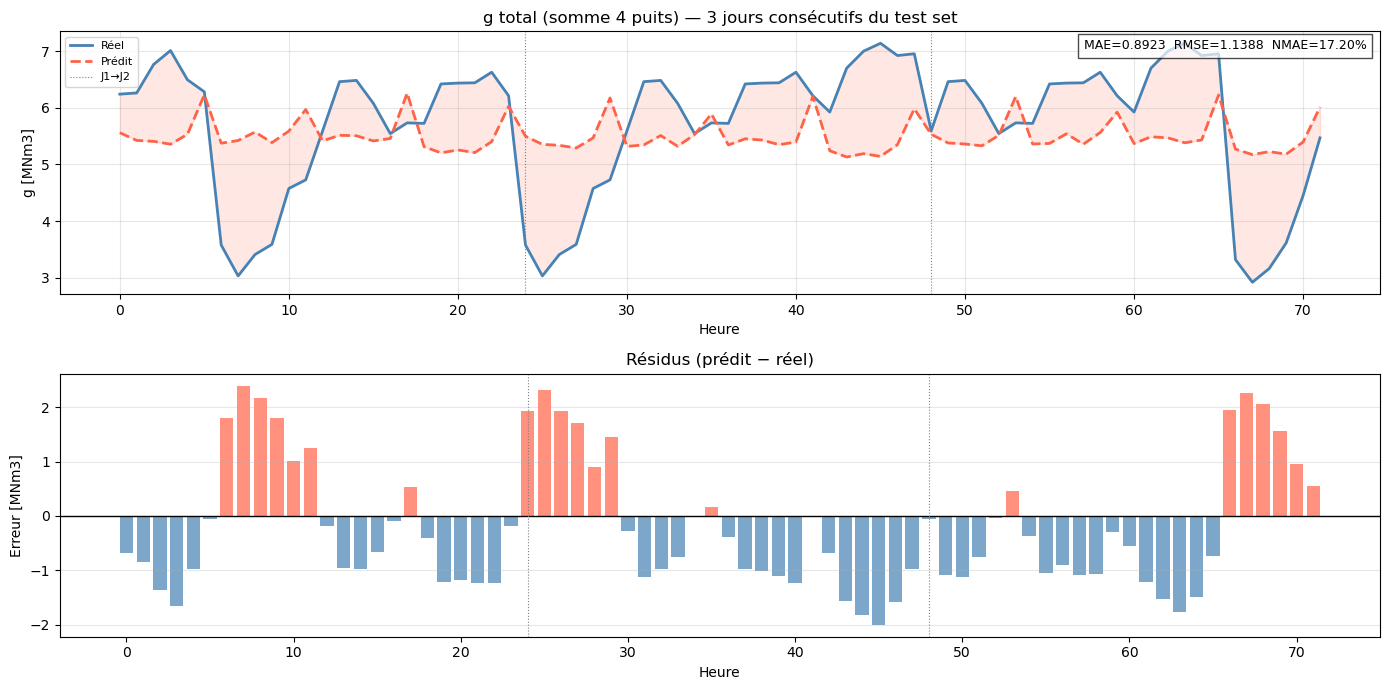

In [10]:
N_DAYS = 3

# Concatène les N_DAYS blocs en séries continues
total_true_cont = np.concatenate([total_true[d] for d in range(N_DAYS)])  # [72]
total_pred_cont = np.concatenate([total_pred[d] for d in range(N_DAYS)])  # [72]
t = np.arange(N_DAYS * 24)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ── Haut : g total ────────────────────────────────────────────────────────────
axes[0].plot(t, total_true_cont, label='Réel',   lw=2, color='steelblue')
axes[0].plot(t, total_pred_cont, label='Prédit', lw=2, color='tomato', ls='--')
axes[0].fill_between(t, total_true_cont, total_pred_cont,
                     alpha=0.15, color='tomato')

# Lignes verticales pour marquer les frontières de blocs
for d in range(1, N_DAYS):
    axes[0].axvline(d * 24, color='grey', lw=0.8, ls=':', label=f'J{d}→J{d+1}' if d == 1 else '')

axes[0].set_title(f'g total (somme 4 puits) — {N_DAYS} jours consécutifs du test set')
axes[0].set_ylabel('g [MNm3]'); axes[0].set_xlabel('Heure')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].text(0.99, 0.97,
             f'MAE={mae_tot:.4f}  RMSE={rmse_tot:.4f}  NMAE={nmae_tot:.2f}%',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7))

# ── Bas : résidus ─────────────────────────────────────────────────────────────
residuals = total_pred_cont - total_true_cont
axes[1].bar(t, residuals,
            color=['tomato' if r > 0 else 'steelblue' for r in residuals],
            alpha=0.7, edgecolor='none')
axes[1].axhline(0, color='black', lw=1)
for d in range(1, N_DAYS):
    axes[1].axvline(d * 24, color='grey', lw=0.8, ls=':')

axes[1].set_title('Résidus (prédit − réel)')
axes[1].set_ylabel('Erreur [MNm3]'); axes[1].set_xlabel('Heure')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

In [11]:
# Vérifie la corrélation q → g sur le train set
# Si >0.9 le modèle mémorise la relation exacte et ne généralise pas
import numpy as np
q_wells = Q_edge_norm[:t_train*24]   # approximatif
g_train = Y_norm[:t_train*24]
print('Corr q→g train:', np.corrcoef(q_wells.mean(axis=1), g_train.mean(axis=1))[0,1])

NameError: name 't_train' is not defined

In [ ]:
# ── CELL DIAGNOSTIC ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 20))

g_tot = g_full.sum(axis=1)  # [T]

# ── 1. Distribution g par puits ───────────────────────────────────────────────
ax1 = fig.add_subplot(4, 3, 1)
for i, name in enumerate(['Node1','Node5','Node17','Node18']):
    ax1.hist(g_full[:, i], bins=50, alpha=0.6, label=name)
ax1.set_title('Distribution g par puits')
ax1.set_xlabel('g [MNm3]'); ax1.legend(fontsize=7)

# ── 2. Corrélation res/ind/exp → g total ──────────────────────────────────────
ax2 = fig.add_subplot(4, 3, 2)
labels = ['res_total', 'ind_total', 'exp_total']
vals   = [np.corrcoef(res_total, g_tot)[0,1],
          np.corrcoef(ind_total, g_tot)[0,1],
          np.corrcoef(exp_total, g_tot)[0,1]]
ax2.bar(labels, vals, color='tomato', edgecolor='black')
ax2.set_title('Corrélation conso → g total')
ax2.set_ylabel('Pearson r'); ax2.set_ylim(-1, 1)
for i, v in enumerate(vals):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# ── 3. Corrélation q_full (pipelines) → g total ───────────────────────────────
ax3 = fig.add_subplot(4, 3, 3)
corrs_q = [np.corrcoef(q_full[:, p], g_tot)[0,1] for p in range(33)]
ax3.bar(range(1, 34), corrs_q, color='steelblue', edgecolor='none')
ax3.axhline(0, color='black', lw=0.8)
ax3.set_title('Corrélation q pipeline → g total')
ax3.set_xlabel('Pipeline'); ax3.set_ylabel('Pearson r')
ax3.set_xticks(range(1, 34, 2))

# ── 4. Série temporelle g total sur toute l'année ─────────────────────────────
ax4 = fig.add_subplot(4, 3, 4)
ax4.plot(g_tot, lw=0.8, color='steelblue')
ax4.axvline(s_train * 24, color='red',    lw=1.5, ls='--', label='train/val')
ax4.axvline(s_val   * 24, color='orange', lw=1.5, ls='--', label='val/test')
ax4.set_title('g total sur toute l\'année')
ax4.set_xlabel('Heure'); ax4.set_ylabel('g [MNm3]'); ax4.legend(fontsize=7)

# ── 5. Distribution g total par split ─────────────────────────────────────────
ax5 = fig.add_subplot(4, 3, 5)
ax5.hist(g_tot[:s_train * 24],            bins=50, alpha=0.6, label='Train', density=True)
ax5.hist(g_tot[s_train*24 : s_val*24],    bins=50, alpha=0.6, label='Val',   density=True)
ax5.hist(g_tot[s_val * 24:],              bins=50, alpha=0.6, label='Test',  density=True)
ax5.set_title('Distribution g total par split')
ax5.set_xlabel('g [MNm3]'); ax5.legend(fontsize=7)

# ── 6. Profil journalier moyen ────────────────────────────────────────────────
ax6 = fig.add_subplot(4, 3, 6)
g_by_hour = [g_tot[h::24].mean() for h in range(24)]
ax6.plot(g_by_hour, marker='o', ms=4, color='steelblue')
ax6.set_title('Profil journalier moyen (g total)')
ax6.set_xlabel('Heure'); ax6.set_ylabel('g moyen [MNm3]')
ax6.set_xticks(range(0, 24, 2)); ax6.grid(alpha=0.3)

# ── 7. Profil mensuel ─────────────────────────────────────────────────────────
ax7 = fig.add_subplot(4, 3, 7)
hours_per_month = [744,672,744,720,744,720,744,744,720,744,720,744]
g_by_month, start = [], 0
for h in hours_per_month:
    g_by_month.append(g_tot[start:start+h].mean())
    start += h
ax7.bar(range(1,13), g_by_month, color='steelblue', edgecolor='black')
ax7.set_title('g total moyen par mois')
ax7.set_xlabel('Mois'); ax7.set_ylabel('g moyen [MNm3]')
ax7.set_xticks(range(1,13))

# ── 8. Loss courbes ───────────────────────────────────────────────────────────
ax8 = fig.add_subplot(4, 3, 8)
ax8.plot(train_losses, label='Train')
ax8.plot(val_losses,   label='Val brute', alpha=0.5)
if len(val_losses) >= SMOOTH_WINDOW:
    smooth = np.convolve(val_losses,
                         np.ones(SMOOTH_WINDOW)/SMOOTH_WINDOW, mode='valid')
    ax8.plot(range(SMOOTH_WINDOW-1, len(val_losses)), smooth,
             label='Val smooth', lw=2)
ax8.set_title('Courbe de loss')
ax8.set_xlabel('Epoch'); ax8.set_ylabel('MSE normalisé'); ax8.legend(fontsize=7)

# ── 9-12. Scatter pred vs réel par puits ──────────────────────────────────────
for i, name in enumerate(['Node1','Node5','Node17','Node18']):
    ax = fig.add_subplot(4, 3, 9 + i)
    true_flat = trues_real[:, :, i].flatten()
    pred_flat = preds_real[:, :, i].flatten()
    ax.scatter(true_flat, pred_flat, alpha=0.05, s=2, color='steelblue')
    lims = [min(true_flat.min(), pred_flat.min()),
            max(true_flat.max(), pred_flat.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='y=x')
    ax.set_title(f'{name} — pred vs réel')
    ax.set_xlabel('Réel'); ax.set_ylabel('Prédit'); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Vérifie la bimodalité de Node 5 et Node 18
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, i, name in zip(axes, [1, 3], ['Node 5', 'Node 18']):
    vals = g_full[:, i]
    ax.hist(vals, bins=100, color='steelblue', edgecolor='none')
    ax.axvline(0.1, color='red', ls='--', label='seuil ~0')
    pct_zero = (vals < 0.1).mean() * 100
    ax.set_title(f'{name} — {pct_zero:.1f}% des heures à ~0')
    ax.set_xlabel('g [MNm3]'); ax.legend()
plt.tight_layout(); plt.show()

# Et la corrélation lag q → g (q de t-1 prédit g de t ?)
from scipy.stats import pearsonr
lags = range(0, 25)
corrs_lag = []
for lag in lags:
    q_pipe1 = q_full[:-lag if lag > 0 else None, 0]   # pipeline 1 (connecté à Node 1)
    g_node1 = g_full[lag:, 0]
    corrs_lag.append(pearsonr(q_pipe1, g_node1)[0])

plt.figure(figsize=(8, 3))
plt.plot(lags, corrs_lag, marker='o', ms=4)
plt.xlabel('Lag (heures)'); plt.ylabel('Corrélation q[pipe1] → g[Node1]')
plt.title('Est-ce que q passé prédit g futur ?')
plt.grid(alpha=0.3); plt.show()